In [1]:
import numpy as np 
import pandas as pd   
import os

In [2]:
df= pd.read_csv("/kaggle/input/airlinedelaycauses/DelayedFlights.csv")
df.head()

/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pan

,Unnamed: 0,Year,Month,DayofMonth,DayOfWeek,DepTime,CRSDepTime,ArrTime,CRSArrTime,UniqueCarrier,...,TaxiIn,TaxiOut,Cancelled,CancellationCode,Diverted,CarrierDelay,WeatherDelay,NASDelay,SecurityDelay,LateAircraftDelay
0,0,2008,1,3,4,2003.0,1955,2211.0,2225,WN,...,4.0,8.0,0,N,0,NaN,NaN,NaN,NaN,NaN
1,1,2008,1,3,4,754.0,735,1002.0,1000,WN,...,5.0,10.0,0,N,0,NaN,NaN,NaN,NaN,NaN
2,2,2008,1,3,4,628.0,620,804.0,750,WN,...,3.0,17.0,0,N,0,NaN,NaN,NaN,NaN,NaN
3,4,2008,1,3,4,1829.0,1755,1959.0,1925,WN,...,3.0,10.0,0,N,0,2.0,0.0,0.0,0.0,32.0
4,5,2008,1,3,4,1940.0,1915,2121.0,2110,WN,...,4.0,10.0,0,N,0,NaN,NaN,NaN,NaN,NaN


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1936758 entries, 0 to 1936757
Data columns (total 30 columns):
 #   Column             Dtype  
---  ------             -----  
 0   Unnamed: 0         int64  
 1   Year               int64  
 2   Month              int64  
 3   DayofMonth         int64  
 4   DayOfWeek          int64  
 5   DepTime            float64
 6   CRSDepTime         int64  
 7   ArrTime            float64
 8   CRSArrTime         int64  
 9   UniqueCarrier      object 
 10  FlightNum          int64  
 11  TailNum            object 
 12  ActualElapsedTime  float64
 13  CRSElapsedTime     float64
 14  AirTime            float64
 15  ArrDelay           float64
 16  DepDelay           float64
 17  Origin             object 
 18  Dest               object 
 19  Distance           int64  
 20  TaxiIn             float64
 21  TaxiOut            float64
 22  Cancelled          int64  
 23  CancellationCode   object 
 24  Diverted           int64  
 25  CarrierDelay      

In [4]:
df.columns.tolist()

['Unnamed: 0',
 'Year',
 'Month',
 'DayofMonth',
 'DayOfWeek',
 'DepTime',
 'CRSDepTime',
 'ArrTime',
 'CRSArrTime',
 'UniqueCarrier',
 'FlightNum',
 'TailNum',
 'ActualElapsedTime',
 'CRSElapsedTime',
 'AirTime',
 'ArrDelay',
 'DepDelay',
 'Origin',
 'Dest',
 'Distance',
 'TaxiIn',
 'TaxiOut',
 'Cancelled',
 'CancellationCode',
 'Diverted',
 'CarrierDelay',
 'WeatherDelay',
 'NASDelay',
 'SecurityDelay',
 'LateAircraftDelay']

In [5]:
np.isinf(df.select_dtypes(include=[np.number])).any()

Unnamed: 0           False
Year                 False
Month                False
DayofMonth           False
DayOfWeek            False
DepTime              False
CRSDepTime           False
ArrTime              False
CRSArrTime           False
FlightNum            False
ActualElapsedTime    False
CRSElapsedTime       False
AirTime              False
ArrDelay             False
DepDelay             False
Distance             False
TaxiIn               False
TaxiOut              False
Cancelled            False
Diverted             False
CarrierDelay         False
WeatherDelay         False
NASDelay             False
SecurityDelay        False
LateAircraftDelay    False
dtype: bool

In [6]:
df.isna().sum()

Unnamed: 0                0
Year                      0
Month                     0
DayofMonth                0
DayOfWeek                 0
DepTime                   0
CRSDepTime                0
ArrTime                7110
CRSArrTime                0
UniqueCarrier             0
FlightNum                 0
TailNum                   5
ActualElapsedTime      8387
CRSElapsedTime          198
AirTime                8387
ArrDelay               8387
DepDelay                  0
Origin                    0
Dest                      0
Distance                  0
TaxiIn                 7110
TaxiOut                 455
Cancelled                 0
CancellationCode          0
Diverted                  0
CarrierDelay         689270
WeatherDelay         689270
NASDelay             689270
SecurityDelay        689270
LateAircraftDelay    689270
dtype: int64

# Remove Outliers

In [7]:
Q1 = df["CarrierDelay"].quantile(0.25)
Q3 = df["CarrierDelay"].quantile(0.75)
IQR = Q3 - Q1

 
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR


df = df[(df["CarrierDelay"] >= lower_bound) & (df["CarrierDelay"] <= upper_bound)]


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1120111 entries, 3 to 1936755
Data columns (total 30 columns):
 #   Column             Non-Null Count    Dtype  
---  ------             --------------    -----  
 0   Unnamed: 0         1120111 non-null  int64  
 1   Year               1120111 non-null  int64  
 2   Month              1120111 non-null  int64  
 3   DayofMonth         1120111 non-null  int64  
 4   DayOfWeek          1120111 non-null  int64  
 5   DepTime            1120111 non-null  float64
 6   CRSDepTime         1120111 non-null  int64  
 7   ArrTime            1120111 non-null  float64
 8   CRSArrTime         1120111 non-null  int64  
 9   UniqueCarrier      1120111 non-null  object 
 10  FlightNum          1120111 non-null  int64  
 11  TailNum            1120109 non-null  object 
 12  ActualElapsedTime  1120111 non-null  float64
 13  CRSElapsedTime     1120111 non-null  float64
 14  AirTime            1120111 non-null  float64
 15  ArrDelay           1120111 non-null  

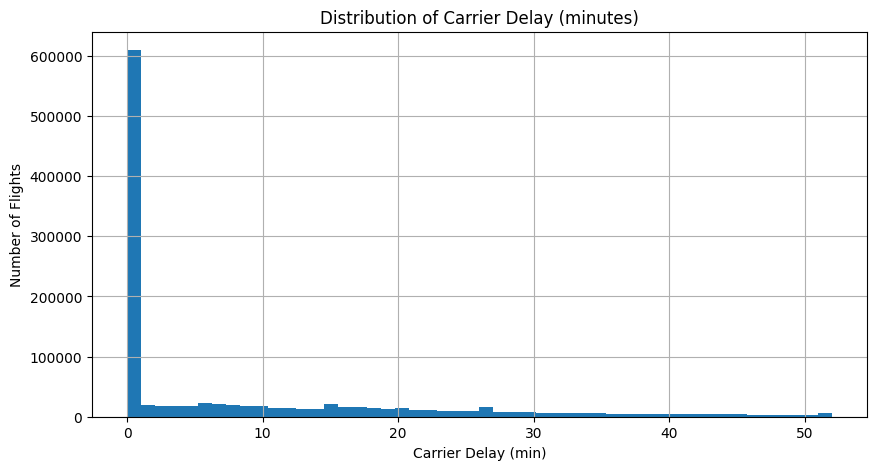

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
df["CarrierDelay"].hist(bins=50)
plt.title("Distribution of Carrier Delay (minutes)")
plt.xlabel("Carrier Delay (min)")
plt.ylabel("Number of Flights")
plt.show()

In [10]:
#replace null values with zero 
delay_cols = ["CarrierDelay", "WeatherDelay", "NASDelay", "SecurityDelay", "LateAircraftDelay"]
df[delay_cols] = df[delay_cols].fillna(0)

In [11]:
df.head()

,Unnamed: 0,Year,Month,DayofMonth,DayOfWeek,DepTime,CRSDepTime,ArrTime,CRSArrTime,UniqueCarrier,...,TaxiIn,TaxiOut,Cancelled,CancellationCode,Diverted,CarrierDelay,WeatherDelay,NASDelay,SecurityDelay,LateAircraftDelay
3,4,2008,1,3,4,1829.0,1755,1959.0,1925,WN,...,3.0,10.0,0,N,0,2.0,0.0,0.0,0.0,32.0
5,6,2008,1,3,4,1937.0,1830,2037.0,1940,WN,...,3.0,7.0,0,N,0,10.0,0.0,0.0,0.0,47.0
7,11,2008,1,3,4,1644.0,1510,1845.0,1725,WN,...,6.0,8.0,0,N,0,8.0,0.0,0.0,0.0,72.0
9,16,2008,1,3,4,1452.0,1425,1640.0,1625,WN,...,7.0,8.0,0,N,0,3.0,0.0,0.0,0.0,12.0
11,18,2008,1,3,4,1323.0,1255,1526.0,1510,WN,...,4.0,9.0,0,N,0,0.0,0.0,0.0,0.0,16.0


In [12]:
#convert time from int num to real time 

def convert_to_time(val):
    val = int(val)
    hour = val // 100
    minute = val % 100
    return f"{hour:02d}:{minute:02d}"

df["DepTime"] = df["DepTime"].apply(convert_to_time)
df["ArrTime"] = df["ArrTime"].apply(convert_to_time)


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1120111 entries, 3 to 1936755
Data columns (total 30 columns):
 #   Column             Non-Null Count    Dtype  
---  ------             --------------    -----  
 0   Unnamed: 0         1120111 non-null  int64  
 1   Year               1120111 non-null  int64  
 2   Month              1120111 non-null  int64  
 3   DayofMonth         1120111 non-null  int64  
 4   DayOfWeek          1120111 non-null  int64  
 5   DepTime            1120111 non-null  object 
 6   CRSDepTime         1120111 non-null  int64  
 7   ArrTime            1120111 non-null  object 
 8   CRSArrTime         1120111 non-null  int64  
 9   UniqueCarrier      1120111 non-null  object 
 10  FlightNum          1120111 non-null  int64  
 11  TailNum            1120109 non-null  object 
 12  ActualElapsedTime  1120111 non-null  float64
 13  CRSElapsedTime     1120111 non-null  float64
 14  AirTime            1120111 non-null  float64
 15  ArrDelay           1120111 non-null  

In [14]:
print(df.shape)   

(1120111, 30)


In [15]:
df = df[df['Cancelled'] == 0]

df = df.rename(columns={
    'TaxiIn': 'TaxiIn (time from landing to gate)',
    'TaxiOut': 'TaxiOut (time from gate to takeoff)',
    'Diverted': 'Diverted (Changed landing ap)',
    'TailNum': 'TailNum (Unique Aircraft identifier)',
    'UniqueCarrier' : 'UniqueCarrier (Airline)',
    'FlightNum':'FlightNum (Route Number)'})

df = df.drop(columns=['Unnamed: 0','DayOfWeek','Cancelled','CancellationCode'])
df.reset_index(drop=True, inplace=True)


In [16]:
df['ActualElapsedTime'].max()

790.0

In [17]:
cols = ['ArrDelay', 'DepDelay', 'CarrierDelay','WeatherDelay','NASDelay','SecurityDelay','LateAircraftDelay']
df[cols] = df[cols].fillna(0)

In [18]:
df.nunique()

Year                                       1
Month                                     12
DayofMonth                                31
DepTime                                 1433
CRSDepTime                              1175
ArrTime                                 1440
CRSArrTime                              1349
UniqueCarrier (Airline)                   20
FlightNum (Route Number)                7473
TailNum (Unique Aircraft identifier)    5342
ActualElapsedTime                        664
CRSElapsedTime                           495
AirTime                                  640
ArrDelay                                 748
DepDelay                                 745
Origin                                   301
Dest                                     301
Distance                                1401
TaxiIn (time from landing to gate)       180
TaxiOut (time from gate to takeoff)      327
Diverted (Changed landing ap)              1
CarrierDelay                              53
WeatherDel

In [19]:
df['TailNum (Unique Aircraft identifier)'].drop_duplicates().shape[0]

5343

In [20]:
df[['Origin','Dest','Distance']].drop_duplicates().shape[0]

5063

In [21]:
df[['UniqueCarrier (Airline)','Origin','Dest','Distance']].drop_duplicates().shape[0]

8168

In [22]:
df['Date'] = pd.to_datetime(df['Year'].astype(str) + '-' + df['Month'].astype(str) + '-' + df['DayofMonth'].astype(str)).dt.date
df = df[['Date'] + [c for c in df.columns if c != 'Date']]

In [23]:
DimDate = df[['Date','Month','DayofMonth']].drop_duplicates().reset_index(drop=True)

In [24]:
df[df.duplicated(['UniqueCarrier (Airline)','FlightNum (Route Number)', 
               'Date', 'TailNum (Unique Aircraft identifier)'])].sort_values(
                by=['FlightNum (Route Number)','Date','TailNum (Unique Aircraft identifier)']).head(100)


,Date,Year,Month,DayofMonth,DepTime,CRSDepTime,ArrTime,CRSArrTime,UniqueCarrier (Airline),FlightNum (Route Number),...,Dest,Distance,TaxiIn (time from landing to gate),TaxiOut (time from gate to takeoff),Diverted (Changed landing ap),CarrierDelay,WeatherDelay,NASDelay,SecurityDelay,LateAircraftDelay
99718,2008-01-01,2008,1,1,11:44,1055,14:59,1359,B6,1,...,FLL,1069,3.0,23.0,0,34.0,0.0,11.0,0.0,15.0
114533,2008-02-11,2008,2,11,08:48,825,09:32,915,WN,1,...,CRP,187,3.0,7.0,0,0.0,0.0,0.0,0.0,17.0
115179,2008-02-12,2008,2,12,09:14,825,10:00,915,WN,1,...,CRP,187,3.0,7.0,0,0.0,0.0,0.0,0.0,45.0
121776,2008-02-21,2008,2,21,09:14,825,10:07,915,WN,1,...,CRP,187,4.0,11.0,0,0.0,0.0,3.0,0.0,49.0
326150,2008-03-01,2008,3,1,08:14,800,11:05,1049,AS,1,...,SEA,2329,4.0,9.0,0,14.0,0.0,2.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
346225,2008-04-10,2008,4,10,10:08,900,13:17,1220,WN,3,...,FLL,957,4.0,7.0,0,0.0,0.0,0.0,0.0,57.0
392202,2008-04-23,2008,4,23,09:21,845,13:02,1223,FL,3,...,MCO,1066,7.0,14.0,0,0.0,0.0,39.0,0.0,0.0
370762,2008-04-25,2008,4,25,16:36,1453,17:11,1530,UA,3,...,KOA,84,2.0,9.0,0,0.0,0.0,2.0,0.0,99.0
460227,2008-05-02,2008,5,2,16:19,1453,16:54,1530,UA,3,...,KOA,84,3.0,11.0,0,0.0,0.0,0.0,0.0,84.0


In [25]:
DimRoute = df[['UniqueCarrier (Airline)','Origin','Dest','Distance']].drop_duplicates().reset_index(drop=True)
DimRoute.index.name = 'FlightNum'

In [26]:
DimAirCraft = df['TailNum (Unique Aircraft identifier)'].drop_duplicates().reset_index(drop=True)
DimAirCraft.index.name = 'AirCraftID'

In [27]:
FactFlights = df[['Date','DepTime','CRSDepTime','ArrTime', 'CRSArrTime', 'TailNum (Unique Aircraft identifier)','ActualElapsedTime',
                  'CRSElapsedTime','AirTime','ArrDelay','DepDelay','TaxiIn (time from landing to gate)','TaxiOut (time from gate to takeoff)',
                  'Diverted (Changed landing ap)', 'CarrierDelay','WeatherDelay','NASDelay','SecurityDelay','LateAircraftDelay',
                  'UniqueCarrier (Airline)', 'Origin', 'Dest', 'Distance']]
FactFlights = FactFlights.merge(
    DimRoute.reset_index(),
    on=['UniqueCarrier (Airline)', 'Origin', 'Dest', 'Distance'],
    how='left')
FactFlights = FactFlights.merge(
    DimAirCraft.reset_index(),
    on=['TailNum (Unique Aircraft identifier)'],
    how='left')
FactFlights.drop(columns=['Origin', 'Dest', 'Distance','UniqueCarrier (Airline)','TailNum (Unique Aircraft identifier)'],inplace=True)

In [28]:
FactFlights = FactFlights[['Date', 'FlightNum', 'AirCraftID'] + 
                          [col for col in FactFlights.columns if col not in ['Date','FlightNum','AirCraftID']]]

In [29]:
FactFlights.head()

,Date,FlightNum,AirCraftID,DepTime,CRSDepTime,ArrTime,CRSArrTime,ActualElapsedTime,CRSElapsedTime,AirTime,ArrDelay,DepDelay,TaxiIn (time from landing to gate),TaxiOut (time from gate to takeoff),Diverted (Changed landing ap),CarrierDelay,WeatherDelay,NASDelay,SecurityDelay,LateAircraftDelay
0,2008-01-03,0,0,18:29,1755,19:59,1925,90.0,90.0,77.0,34.0,34.0,3.0,10.0,0,2.0,0.0,0.0,0.0,32.0
1,2008-01-03,1,1,19:37,1830,20:37,1940,240.0,250.0,230.0,57.0,67.0,3.0,7.0,0,10.0,0.0,0.0,0.0,47.0
2,2008-01-03,2,2,16:44,1510,18:45,1725,121.0,135.0,107.0,80.0,94.0,6.0,8.0,0,8.0,0.0,0.0,0.0,72.0
3,2008-01-03,3,3,14:52,1425,16:40,1625,228.0,240.0,213.0,15.0,27.0,7.0,8.0,0,3.0,0.0,0.0,0.0,12.0
4,2008-01-03,4,4,13:23,1255,15:26,1510,123.0,135.0,110.0,16.0,28.0,4.0,9.0,0,0.0,0.0,0.0,0.0,16.0


In [30]:
DimRoute.head()

,UniqueCarrier (Airline),Origin,Dest,Distance
FlightNum,,,,
0,WN,IND,BWI,515
1,WN,IND,LAS,1591
2,WN,IND,MCO,828
3,WN,IND,PHX,1489
4,WN,IND,TPA,838


In [31]:
DimDate.head()

,Date,Month,DayofMonth
0,2008-01-03,1,3
1,2008-01-04,1,4
2,2008-01-05,1,5
3,2008-01-06,1,6
4,2008-01-07,1,7


In [32]:
DimAirCraft.head()

AirCraftID
0    N464WN
1    N763SW
2    N334SW
3    N286WN
4    N674AA
Name: TailNum (Unique Aircraft identifier), dtype: object

# Save the Models

In [33]:
FactFlights.to_csv('~\Desktop\ITI\PBI\Day06\FactFlights.csv', index=False)
DimRoute.to_csv('~\Desktop\ITI\PBI\Day06\DimRoute.csv')
DimDate.to_csv('~\Desktop\ITI\PBI\Day06\DimDate.csv', index=False)
DimAirCraft.to_csv('~\Desktop\ITI\PBI\Day06\DimAirCraft.csv')